# Likelihood comparison: Gaussian vs. Binomial vs. Bernoulli

The main `nick_analysis.ipynb` fits the sinusoidal quenched-fraction model
$f_q(\theta) = a + b\cos(2\theta)$ to *binned* quenched fractions with a
Gaussian log-likelihood (plus a jitter term $f$). Because some angular bins
have small satellite counts (as low as $n_i = 11$ in the smallest bin) and
per-bin quenched fractions are not always close to 0.5, the
binomial-to-Gaussian normal approximation is a known concern. This notebook
re-runs the MCMC under two alternative likelihoods that don't make that
approximation:

1. **Gaussian binned** (the current one, kept as baseline)
2. **Binomial binned** — treats each bin's quenched count $k_i$ as
   $\mathrm{Binomial}(n_i, p_i)$ with $p_i = a + b\cos(2\theta_i)$
3. **Unbinned Bernoulli** — uses the raw per-satellite $(\theta_j, q_j)$
   with $p(\theta_j) = a + b\cos(2\theta_j)$

**Nothing in `nick_analysis.ipynb` is modified.** The setup cells below
(data loading, cuts, angle calculation, binning) are duplicated verbatim
from `nick_analysis.ipynb` so this notebook is self-contained; that
duplicated section is called out with markdown flags and is followed by a
sanity check confirming reproduction of the same $f_{q,i}$, $s_i$, $n_i$
used by the current fit.

---
## Section A. Setup duplicated from `nick_analysis.ipynb`

> **The cells in this section are copied verbatim (aside from stripping
> unrelated plotting and the TNG100 branch) from `nick_analysis.ipynb`.**
> They are here only to reproduce the same `saga_90` / `saga_quenched` /
> `elves_90_correct` / `elves_quenched` arrays that the existing likelihood
> function consumes. Skip to Section B for the new likelihood-comparison
> code being tested.

### A.1 Imports (copied)

In [1]:
# Core numerical / plotting stack
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Statistics
import scipy.stats
from scipy import stats

# Astronomy utilities
import astropy.units as u
import astropy.constants as const
from astropy.table import Table, join
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18 as cosmo
from astroquery.simbad import Simbad

# MCMC fitting
import emcee
import corner

/Users/nicolasgarcia/opt/anaconda3/envs/py311-main/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.4.3)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


### A.2 SAGA: load, r200c cut, per-satellite projected angle (copied)

In [2]:
# combine table C1 and C3, attach host properties to each satellite
saga_host_path = '../saga-dr3-tableC1.txt'
saga_sats_path = '../saga-dr3-tableC3.txt'
saga_hosts = Table.read(saga_host_path, format='ascii')
saga_sats = Table.read(saga_sats_path, format='ascii')
saga_joined = join(saga_sats, saga_hosts, 'HOSTID', 'left',
                   uniq_col_name='{table_name}{col_name}',
                   table_names=['', 'HOST_'])
print(len(saga_joined))

378


In [3]:
# r200 calculation, from Jingyao
def calc_r200(mhalo, do_print=False):
    mhalo = mhalo * u.Msun
    delta = 200
    rho_c = cosmo.critical_density0
    r200_c = ((3 * mhalo / (4. * np.pi * delta * rho_c)) ** (1. / 3.)).to(u.kpc)
    rho_m = cosmo.critical_density0 * cosmo.Om0
    r200_m = ((3 * mhalo / (4. * np.pi * delta * rho_m)) ** (1. / 3.)).to(u.kpc)
    return r200_c.value, r200_m.value

hosts_log_mhalo_array = saga_hosts['log(Mhalo)'].data
r200c, r200m = calc_r200(10 ** hosts_log_mhalo_array)

In [4]:
# Compute each SAGA satellite's projected offset angle relative to host PA
saga_PA = np.zeros(len(saga_sats))
saga_quenched = saga_sats['quenched'].data
for m in range(len(saga_hosts)):
    h_c = SkyCoord(saga_hosts['RAdeg'][m], saga_hosts['DEdeg'][m], frame="icrs", unit="deg")
    for n in range(len(saga_sats)):
        if saga_hosts['HOSTID'][m] == saga_sats['HOSTID'][n]:
            PA = saga_hosts['PA'][m]
            s_c = SkyCoord(saga_sats['RAdeg'][n], saga_sats['DEdeg'][n], frame="icrs", unit="deg")
            relative_angle = h_c.position_angle(s_c).degree
            relative_angle_corrected = 90 + relative_angle
            angle_final = ((90 - PA) + relative_angle_corrected) % 360
            saga_PA[n] = angle_final

In [5]:
def map_to_0_90(angles):
    angles = np.mod(angles, 360)
    return np.where(angles <= 90, angles,
           np.where(angles <= 180, 180 - angles,
           np.where(angles <= 270, angles - 180,
                    360 - angles)))

In [6]:
# radius (r200c) cut per satellite
r200c_hosts = np.zeros(len(saga_sats))
sats_rhost_array = saga_sats['Rhost'].data
host_data = {saga_hosts['HOSTID'][i]: hosts_log_mhalo_array[i] for i in range(len(saga_hosts))}
for i in range(len(saga_sats)):
    host_id = saga_sats['HOSTID'][i]
    if host_id in host_data:
        mhalo = 10 ** host_data[host_id]
        r200c_i, _ = calc_r200(mhalo)
        r200c_hosts[i] = r200c_i
sample = np.array(saga_sats['sample'])

In [7]:
# Final SAGA sample: r200c cut + gold+silver (sample codes 1 or 2)
index_final = (sats_rhost_array < r200c_hosts) & ((sample == 1.) | (sample == 2.))
saga_PA = saga_PA[index_final]
saga_90 = map_to_0_90(saga_PA)
saga_quenched = saga_quenched[index_final]
print("SAGA final N satellites:", len(saga_90))

SAGA final N satellites: 269


### A.3 ELVES: load, per-satellite angle, keep hosts with valid SIMBAD PA (copied)

In [8]:
sats = pd.read_csv('../Carlsten22_ELVES_confirmed_sats - Carlsten22_ELVES_confirmed_sats_compre.csv')
hosts_unfiltered = pd.read_csv(
    "../Carlsten22_ELVES_host - Carlsten22_ELVES_host.csv",
    skipfooter=1, engine="python",
)

customSimbad = Simbad()
customSimbad.reset_votable_fields()
customSimbad.add_votable_fields('ra', 'dec', 'galdim_angle', 'galdim_majaxis', 'galdim_minaxis')

In [9]:
# Compute per-ELVES-satellite projected angle. Only rows whose host has a
# valid SIMBAD PA are kept (elves_PA + kept_indices below), mirroring
# nick_analysis.ipynb.
pa_list = []
kept_indices = []
for r in range(len(sats)):
    host = sats['Host'].get(r)
    h_table = Simbad.query_object(host)
    pa_tab = customSimbad.query_object(host)
    pa_col = pa_tab['galdim_angle']
    if np.ma.is_masked(pa_col):
        continue
    try:
        h_coords = SkyCoord(ra=h_table['ra'], dec=h_table['dec'], frame='icrs')
        s_coords = SkyCoord(ra=sats['RA(deg)'].get(r),
                            dec=sats['DEC(deg)'].get(r),
                            frame='icrs', unit='deg')
    except Exception:
        continue
    position_angle = h_coords.position_angle(s_coords).degree
    angle = ((90 - pa_col.value) + position_angle + 90) % 360
    pa_list.append(angle)
    kept_indices.append(r)

elves_PA = np.array(pa_list, dtype=float)

elves_quenched = sats['ETG?'].iloc[kept_indices]

# Fold ELVES angles to 0-90 and unwrap the 1-element masked-array-per-row
# format that map_to_0_90 returns for the ELVES arrays.
elves_90 = map_to_0_90(elves_PA)
elves_90_correct = []
for i in range(len(elves_90)):
    elves_90_correct.append(elves_90[i][0])
elves_90_correct = np.array(elves_90_correct)
elves_quenched = np.array(elves_quenched)
print("ELVES final N satellites:", len(elves_90_correct))

ELVES final N satellites: 177


### A.4 Bootstrap binning into $f_{q,i}$, $s_i$ (copied)

This is the exact function from `nick_analysis.ipynb`. It fixes bin
membership from the real data and resamples *within* each bin with
replacement, so `fq_std` is the per-bin bootstrap 1-sigma on the fraction
— **not** a naive $\sqrt{p(1-p)/n}$ Wald estimator.

In [10]:
def bootstrap_90_observational_binned(x, y, N=10000, bins=18, angle_range=(0, 90)):
    x = np.asarray(x)
    y = np.asarray(y, dtype=float)
    bin_edges = np.linspace(angle_range[0], angle_range[1], bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    fq_mean = np.full(bins, np.nan)
    fq_std = np.full(bins, np.nan)
    rng = np.random.default_rng()
    for j in range(bins):
        in_bin = (x >= bin_edges[j]) & (x < bin_edges[j + 1])
        y_bin = y[in_bin]
        n_bin = len(y_bin)
        if n_bin < 2:
            continue
        idx = rng.integers(0, n_bin, size=(N, n_bin))
        boot_fq = y_bin[idx].mean(axis=1)
        fq_mean[j] = boot_fq.mean()
        fq_std[j] = boot_fq.std()
    return bin_centers, fq_mean, fq_std

In [11]:
# Reproduce the same fq_mean_saga, fq_std_saga, fq_mean_elves, fq_std_elves
# arrays that `nick_analysis.ipynb`'s main MCMC fit consumes: 18 bins over 0-90.
np.random.seed(42)
bin_centers, fq_mean_saga, fq_std_saga = bootstrap_90_observational_binned(saga_90, saga_quenched, N=10000)
bin_centers, fq_mean_elves, fq_std_elves = bootstrap_90_observational_binned(elves_90_correct, elves_quenched, N=10000)

angle_array = np.loadtxt('../angle_array.txt')
assert np.allclose(bin_centers, angle_array), "bin_centers mismatch with angle_array.txt"

---
## Section B. New: likelihood-comparison work

From here on, everything is new code written for this notebook, using the
arrays reproduced above.

### B.1 Per-bin counts $n_i$ and quenched counts $k_i$

`bootstrap_90_observational_binned` doesn't return $n_i$, so compute the
per-bin counts explicitly. Also compute the naive empirical $\hat p_i =
k_i/n_i$ and confirm it matches the bootstrap-mean `fq_mean` (bootstrap
with-replacement means are unbiased estimators of the sample mean).

In [12]:
def per_bin_counts(theta, q, bins=18, angle_range=(0, 90)):
    edges = np.linspace(angle_range[0], angle_range[1], bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    n_i, _ = np.histogram(theta, bins=edges)
    q_bool = np.asarray(q, dtype=float) > 0.5
    k_i, _ = np.histogram(theta[q_bool], bins=edges)
    return centers, n_i, k_i

bin_centers_check, n_saga, k_saga = per_bin_counts(saga_90, saga_quenched)
_, n_elves, k_elves = per_bin_counts(elves_90_correct, elves_quenched)
assert np.allclose(bin_centers_check, bin_centers)

phat_saga = np.where(n_saga > 0, k_saga / np.where(n_saga > 0, n_saga, 1), np.nan)
phat_elves = np.where(n_elves > 0, k_elves / np.where(n_elves > 0, n_elves, 1), np.nan)

df_saga = pd.DataFrame({
    "bin_center_deg": bin_centers,
    "n_i": n_saga,
    "k_i": k_saga,
    "p_hat = k_i/n_i": phat_saga,
    "fq_mean (bootstrap)": fq_mean_saga,
    "fq_std (bootstrap)": fq_std_saga,
})
df_elves = pd.DataFrame({
    "bin_center_deg": bin_centers,
    "n_i": n_elves,
    "k_i": k_elves,
    "p_hat = k_i/n_i": phat_elves,
    "fq_mean (bootstrap)": fq_mean_elves,
    "fq_std (bootstrap)": fq_std_elves,
})

print("SAGA per-bin summary:")
print(df_saga.to_string(index=False))
print()
print("ELVES per-bin summary:")
print(df_elves.to_string(index=False))

SAGA per-bin summary:
 bin_center_deg  n_i  k_i  p_hat = k_i/n_i  fq_mean (bootstrap)  fq_std (bootstrap)
            2.5   13    5         0.384615             0.384638            0.134250
            7.5   14    4         0.285714             0.284971            0.119989
           12.5   13    2         0.153846             0.154169            0.099191
           17.5   19    5         0.263158             0.265158            0.103450
           22.5   17    3         0.176471             0.176753            0.092493
           27.5   10    2         0.200000             0.199210            0.126445
           32.5   14    7         0.500000             0.499371            0.134891
           37.5   11    3         0.272727             0.273382            0.135034
           42.5    8    1         0.125000             0.125663            0.116450
           47.5   18    2         0.111111             0.110828            0.074014
           52.5   19    5         0.263158            

**Sanity check.** In each dataset the naive empirical fraction $\hat p_i =
k_i / n_i$ should match `fq_mean` (bootstrap-mean per bin) to a few parts
in $10^3$ — confirming the copied setup reproduces the same $f_{q,i}$ /
$s_i$ / $n_i$ that feed `nick_analysis.ipynb`'s main plots.

In [13]:
valid_saga_check = np.isfinite(fq_mean_saga) & (n_saga > 0)
valid_elves_check = np.isfinite(fq_mean_elves) & (n_elves > 0)
max_dev_saga = np.max(np.abs(phat_saga[valid_saga_check] - fq_mean_saga[valid_saga_check]))
max_dev_elves = np.max(np.abs(phat_elves[valid_elves_check] - fq_mean_elves[valid_elves_check]))
print(f"Max |p_hat - fq_mean| SAGA:  {max_dev_saga:.4f}")
print(f"Max |p_hat - fq_mean| ELVES: {max_dev_elves:.4f}")

Max |p_hat - fq_mean| SAGA:  0.0020
Max |p_hat - fq_mean| ELVES: 0.0049


### B.2 Normal-approximation rule-of-thumb: $n_i p_i (1-p_i)$ and $n_i p_i \geq 5$

Standard threshold for the binomial-to-normal approximation to be reasonable:
$n_i p_i \geq 5$ **and** $n_i (1 - p_i) \geq 5$. Bins that fail this on
either side are the ones where the Gaussian likelihood is most suspect.

In [14]:
def normal_approx_check(df, label):
    n = df["n_i"].to_numpy()
    p = df["p_hat = k_i/n_i"].to_numpy()
    npq = n * p * (1 - p)
    npos = n * p
    nneg = n * (1 - p)
    ok = (npos >= 5) & (nneg >= 5)
    out = df.copy()
    out["n*p*(1-p)"] = npq
    out["n*p"] = npos
    out["n*(1-p)"] = nneg
    out["normal_ok"] = ok
    print(f"\n{label}: normal-approx status per bin")
    print(out[["bin_center_deg", "n_i", "k_i", "p_hat = k_i/n_i",
               "n*p", "n*(1-p)", "n*p*(1-p)", "normal_ok"]].to_string(index=False))
    bad = out[~ok]
    print(f"  {label}: {len(bad)} of {len(out)} bins fail (n*p >= 5 AND n*(1-p) >= 5).")
    if len(bad) > 0:
        print(f"  Failing bin centers [deg]: {list(np.round(bad['bin_center_deg'].to_numpy(), 2))}")
        print(f"  Smallest n_i in sample: {int(n.min())}")
    return out

diag_saga = normal_approx_check(df_saga, "SAGA")
diag_elves = normal_approx_check(df_elves, "ELVES")


SAGA: normal-approx status per bin
 bin_center_deg  n_i  k_i  p_hat = k_i/n_i  n*p  n*(1-p)  n*p*(1-p)  normal_ok
            2.5   13    5         0.384615  5.0      8.0   3.076923       True
            7.5   14    4         0.285714  4.0     10.0   2.857143      False
           12.5   13    2         0.153846  2.0     11.0   1.692308      False
           17.5   19    5         0.263158  5.0     14.0   3.684211       True
           22.5   17    3         0.176471  3.0     14.0   2.470588      False
           27.5   10    2         0.200000  2.0      8.0   1.600000      False
           32.5   14    7         0.500000  7.0      7.0   3.500000       True
           37.5   11    3         0.272727  3.0      8.0   2.181818      False
           42.5    8    1         0.125000  1.0      7.0   0.875000      False
           47.5   18    2         0.111111  2.0     16.0   1.777778      False
           52.5   19    5         0.263158  5.0     14.0   3.684211       True
           57.5 

### B.3 Three log-likelihood implementations

Priors match `nick_analysis.ipynb`'s existing setup: $0 < a < 1$, $-1 < b <
1$. The Gaussian likelihood **also** keeps the existing $-10 < \ln f < 2$
jitter parameter (so it exactly matches the current fit); the binomial and
Bernoulli likelihoods have no jitter — they use only $(a, b)$.

Model: $p(\theta) = a + b \cos(2\theta)$. We evaluate it in radians on
`bin_centers` (degrees) or per-satellite $\theta_j$, and clip $p$ to
$[10^{-6}, 1 - 10^{-6}]$ before taking logs.

In [15]:
CLIP_LOW, CLIP_HIGH = 1e-6, 1 - 1e-6

def model_p(theta_deg, a, b):
    return a + b * np.cos(2 * np.radians(theta_deg))

def _clip(p):
    return np.clip(p, CLIP_LOW, CLIP_HIGH)

# --- Gaussian binned (current, 3 params: a, b, ln f) ------------------------
def loglike_gaussian(params, theta_deg, fq, sig):
    a, b, lnf = params
    s2 = sig ** 2 + np.exp(lnf) ** 2
    mu = model_p(theta_deg, a, b)
    return -0.5 * np.sum((fq - mu) ** 2 / s2 + np.log(2 * np.pi * s2))

def logprior_gaussian(params):
    a, b, lnf = params
    if 0 < a < 1 and -1 < b < 1 and -10 < lnf < 2:
        return 0.0
    return -np.inf

def logpost_gaussian(params, theta_deg, fq, sig):
    lp = logprior_gaussian(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + loglike_gaussian(params, theta_deg, fq, sig)

# --- Binomial binned (2 params: a, b) --------------------------------------
# ln C(n, k) is a constant in (a, b) so it does not affect posteriors, but we
# include it via scipy.stats.binom.logpmf for correctness / diagnostic value.
def loglike_binomial(params, theta_deg, n_i, k_i):
    a, b = params
    p = _clip(model_p(theta_deg, a, b))
    return np.sum(scipy.stats.binom.logpmf(k_i, n_i, p))

def logprior_ab(params):
    a, b = params
    if 0 < a < 1 and -1 < b < 1:
        return 0.0
    return -np.inf

def logpost_binomial(params, theta_deg, n_i, k_i):
    lp = logprior_ab(params)
    if not np.isfinite(lp):
        return -np.inf
    # p(theta) must stay inside (0, 1) across ALL bins for the binomial
    # likelihood to be defined without relying on the clip. Reject params
    # that push any bin's p outside (0, 1).
    a, b = params
    p_all = model_p(theta_deg, a, b)
    if np.any(p_all <= 0) or np.any(p_all >= 1):
        return -np.inf
    return lp + loglike_binomial(params, theta_deg, n_i, k_i)

# --- Unbinned Bernoulli (2 params: a, b) -----------------------------------
def loglike_bernoulli(params, theta_j_deg, q_j):
    a, b = params
    p = _clip(model_p(theta_j_deg, a, b))
    return np.sum(q_j * np.log(p) + (1.0 - q_j) * np.log(1.0 - p))

def logpost_bernoulli(params, theta_j_deg, q_j):
    lp = logprior_ab(params)
    if not np.isfinite(lp):
        return -np.inf
    a, b = params
    p_all = model_p(theta_j_deg, a, b)
    if np.any(p_all <= 0) or np.any(p_all >= 1):
        return -np.inf
    return lp + loglike_bernoulli(params, theta_j_deg, q_j)

### B.4 Run MCMC for all three likelihoods, for both SAGA and ELVES

Walker count (20), step count (10000), burn-in (1000), and initial guess
for $(a, b, \ln f)$ (or its 2D subset for binomial/Bernoulli) all match
`nick_analysis.ipynb`'s existing `run_mcmc_fit` setup.

In [16]:
N_WALKERS = 20
N_STEPS = 10000
BURNIN = 1000
INIT_ABF = np.array([0.7, 0.025, -3.0])  # matches nick_analysis.ipynb
INIT_AB = INIT_ABF[:2]

def run_sampler(logpost, args, init, seed=0):
    rng = np.random.default_rng(seed)
    ndim = len(init)
    pos = np.array(init) + rng.normal(size=(N_WALKERS, ndim)) * 1e-2
    sampler = emcee.EnsembleSampler(N_WALKERS, ndim, logpost, args=args)
    sampler.run_mcmc(pos, N_STEPS, progress=False)
    return sampler.get_chain(discard=BURNIN, flat=True)

# For each dataset, drop bins that the bootstrap left as NaN (matches the
# `valid_saga`/`valid_elves` guard in nick_analysis.ipynb's main fit).
valid_saga = np.isfinite(fq_mean_saga) & np.isfinite(fq_std_saga) & (fq_std_saga > 0) & (n_saga > 0)
valid_elves = np.isfinite(fq_mean_elves) & np.isfinite(fq_std_elves) & (fq_std_elves > 0) & (n_elves > 0)
print(f"SAGA usable bins:  {valid_saga.sum()} / {len(valid_saga)}")
print(f"ELVES usable bins: {valid_elves.sum()} / {len(valid_elves)}")

SAGA usable bins:  18 / 18
ELVES usable bins: 18 / 18


In [17]:
results = {}

for name, mask, fq_mean, fq_std, n_i, k_i, theta_j, q_j in [
    ("SAGA", valid_saga, fq_mean_saga, fq_std_saga, n_saga, k_saga, saga_90, saga_quenched),
    ("ELVES", valid_elves, fq_mean_elves, fq_std_elves, n_elves, k_elves, elves_90_correct, elves_quenched),
]:
    tc = bin_centers[mask]
    fqm = fq_mean[mask]
    fqs = fq_std[mask]
    ni = n_i[mask]
    ki = k_i[mask]

    print(f"\n--- {name}: running MCMC (Gaussian, Binomial, Bernoulli) ---")
    print(f"    Gaussian ({len(tc)} bins)...")
    samp_g = run_sampler(logpost_gaussian, (tc, fqm, fqs), INIT_ABF, seed=1)
    print(f"    Binomial ({len(tc)} bins)...")
    samp_b = run_sampler(logpost_binomial, (tc, ni, ki), INIT_AB, seed=2)
    print(f"    Bernoulli ({len(theta_j)} satellites, unbinned)...")
    samp_r = run_sampler(logpost_bernoulli,
                         (np.asarray(theta_j, dtype=float),
                          np.asarray(q_j, dtype=float)),
                         INIT_AB, seed=3)

    results[name] = {
        "Gaussian": samp_g,   # cols: a, b, lnf
        "Binomial": samp_b,   # cols: a, b
        "Bernoulli": samp_r,  # cols: a, b
    }


--- SAGA: running MCMC (Gaussian, Binomial, Bernoulli) ---
    Gaussian (18 bins)...


    Binomial (18 bins)...


    Bernoulli (269 satellites, unbinned)...



--- ELVES: running MCMC (Gaussian, Binomial, Bernoulli) ---
    Gaussian (18 bins)...


    Binomial (18 bins)...


    Bernoulli (177 satellites, unbinned)...


### B.5 Compare posteriors on $(a, b)$

For each dataset, report the posterior median and 16-84 percentile
interval on $a$ and on $b$ under each likelihood. Then quantify:

- **Shift in $b$**: $|b_{\text{Gaussian}} - b_{\text{alt}}|$ compared to
  $\sigma_b$ from the Gaussian fit — is the shift larger than the
  statistical uncertainty on $b$?
- **Significance of $b$**: for each likelihood, the fraction of posterior
  samples with $b > 0$ (a one-sided "is $b$ different from zero" check),
  converted to a two-sided z-equivalent.

In [18]:
def median_ci(x):
    lo, med, hi = np.percentile(x, [16, 50, 84])
    return med, med - lo, hi - med

def significance_bgt0(b_samples):
    frac = np.mean(b_samples > 0)
    # Two-sided z-equivalent
    p_two_sided = 2 * min(frac, 1 - frac)
    if p_two_sided <= 0:
        z_eq = float("inf")
    else:
        z_eq = scipy.stats.norm.ppf(1 - p_two_sided / 2)
    return frac, z_eq

summary_rows = []
for dataset, by_like in results.items():
    b_gauss = by_like["Gaussian"][:, 1]
    b_gauss_std = float(np.std(b_gauss))
    for like_name, samples in by_like.items():
        a_med, a_lo, a_hi = median_ci(samples[:, 0])
        b_med, b_lo, b_hi = median_ci(samples[:, 1])
        frac_bpos, z_eq = significance_bgt0(samples[:, 1])
        row = {
            "dataset": dataset,
            "likelihood": like_name,
            "a_median": a_med,
            "a_-1sig": a_lo,
            "a_+1sig": a_hi,
            "b_median": b_med,
            "b_-1sig": b_lo,
            "b_+1sig": b_hi,
            "P(b>0)": frac_bpos,
            "|b|/sigma_b (two-sided)": z_eq,
        }
        if like_name != "Gaussian":
            shift = b_med - np.median(b_gauss)
            row["b shift vs Gaussian"] = shift
            row["|shift| / sigma_b(Gauss)"] = abs(shift) / b_gauss_std if b_gauss_std > 0 else float("nan")
        else:
            row["b shift vs Gaussian"] = 0.0
            row["|shift| / sigma_b(Gauss)"] = 0.0
        summary_rows.append(row)

summary = pd.DataFrame(summary_rows)
pd.set_option("display.float_format", lambda x: f"{x: .4f}")
print(summary.to_string(index=False))

dataset likelihood  a_median  a_-1sig  a_+1sig  b_median  b_-1sig  b_+1sig  P(b>0)  |b|/sigma_b (two-sided)  b shift vs Gaussian  |shift| / sigma_b(Gauss)
   SAGA   Gaussian    0.2504   0.0268   0.0276   -0.0366   0.0390   0.0389  0.1752                   0.9338               0.0000                    0.0000
   SAGA   Binomial    0.2837   0.0270   0.0276   -0.0412   0.0360   0.0361  0.1289                   1.1314              -0.0046                    0.1147
   SAGA  Bernoulli    0.2839   0.0270   0.0275   -0.0413   0.0363   0.0374  0.1361                   1.0981              -0.0047                    0.1180
  ELVES   Gaussian    0.6323   0.0452   0.0418    0.0389   0.0597   0.0578  0.7443                   0.6566               0.0000                    0.0000
  ELVES   Binomial    0.6188   0.0361   0.0353    0.0302   0.0493   0.0492  0.7261                   0.6009              -0.0087                    0.1388
  ELVES  Bernoulli    0.6185   0.0363   0.0358    0.0302   0.0490   0.

**Interpretation guide.** `|shift| / sigma_b(Gauss)` above quantifies how
much the posterior on $b$ moves between the Gaussian and each alternative,
in units of the Gaussian statistical uncertainty. `|b|/sigma_b (two-sided)`
is a rough z-equivalent for excluding $b = 0$ under each likelihood — a
change in this value across likelihoods flags a change in the significance
of the anisotropy detection.

### B.6 Overlaid posterior comparison plots

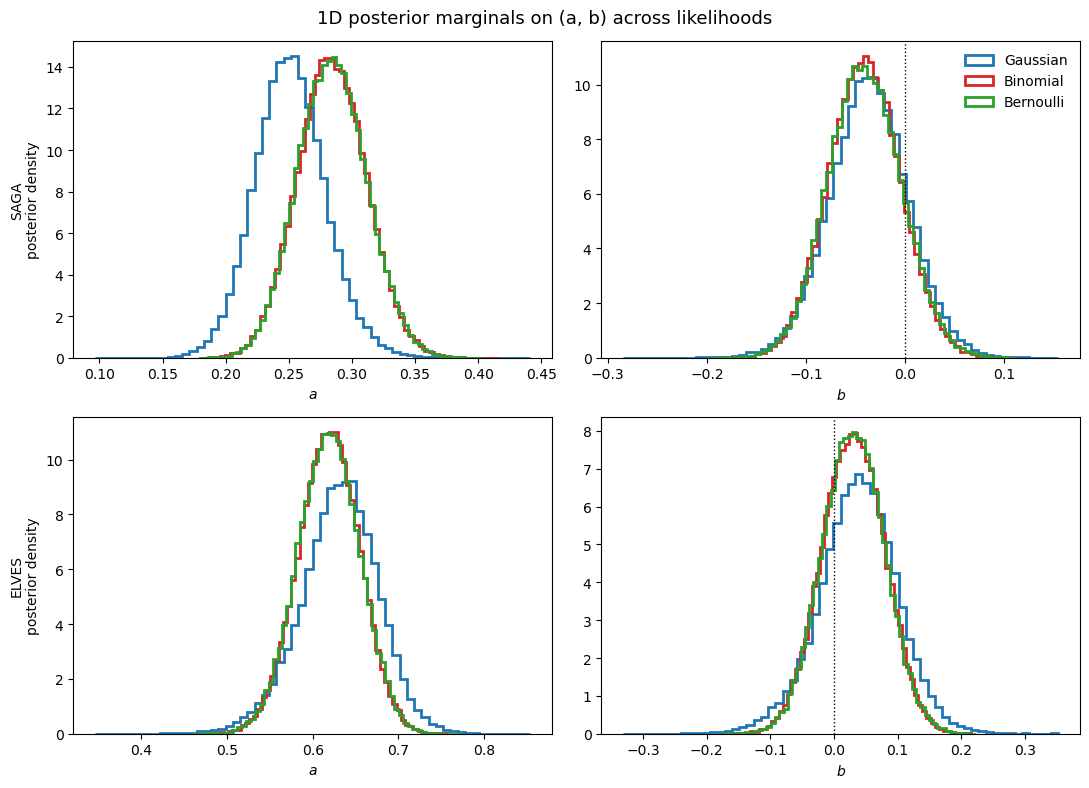

In [19]:
LIKE_COLORS = {"Gaussian": "#1f77b4", "Binomial": "#d62728", "Bernoulli": "#2ca02c"}

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for row, dataset in enumerate(["SAGA", "ELVES"]):
    for col, param_idx, param_label in [(0, 0, r"$a$"), (1, 1, r"$b$")]:
        ax = axes[row, col]
        for like_name, samples in results[dataset].items():
            ax.hist(samples[:, param_idx], bins=60, density=True, histtype="step",
                    lw=2, color=LIKE_COLORS[like_name], label=like_name)
        ax.set_xlabel(param_label)
        if col == 0:
            ax.set_ylabel(f"{dataset}\nposterior density")
        if row == 0 and col == 1:
            ax.legend(fontsize=10, frameon=False)
        if param_idx == 1:
            ax.axvline(0, color="k", ls=":", lw=1)
fig.suptitle("1D posterior marginals on (a, b) across likelihoods", fontsize=13)
fig.tight_layout()
plt.show()

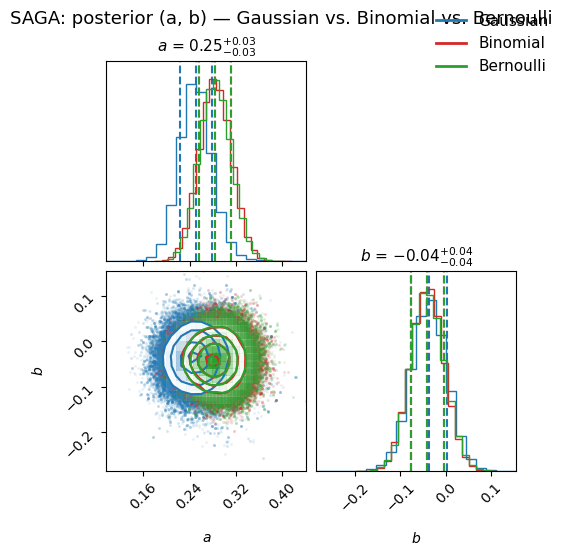

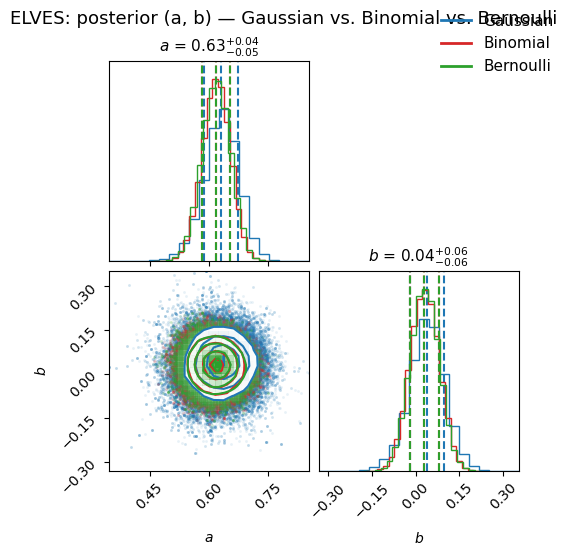

In [20]:
# Overlaid corner plot of (a, b) for each dataset
for dataset in ["SAGA", "ELVES"]:
    fig = None
    for i, (like_name, samples) in enumerate(results[dataset].items()):
        color = LIKE_COLORS[like_name]
        # Take only the (a, b) columns — Gaussian has a 3rd (lnf) column
        ab = samples[:, :2]
        fig = corner.corner(
            ab, labels=[r"$a$", r"$b$"], fig=fig, color=color,
            show_titles=(i == 0), title_kwargs={"fontsize": 11},
            quantiles=[0.16, 0.5, 0.84], hist_kwargs={"density": True},
        )
    handles = [plt.Line2D([0], [0], color=LIKE_COLORS[k], lw=2, label=k)
               for k in results[dataset].keys()]
    fig.legend(handles=handles, loc="upper right", frameon=False, fontsize=11)
    fig.suptitle(f"{dataset}: posterior (a, b) — Gaussian vs. Binomial vs. Bernoulli",
                 y=1.02, fontsize=13)
    plt.show()

### B.7 Bin-count sweep

Everything above uses the same 18-bin grid as `nick_analysis.ipynb`'s
main fit. The Gaussian and binomial likelihoods both depend on binning
(through $f_{q,i}$/$s_i$ for Gaussian, through $k_i$/$n_i$ for binomial),
so their posteriors can shift with bin count. The Bernoulli likelihood is
unbinned and therefore independent of the bin choice — it enters this
section as a constant reference line.

For each bin count in `BIN_SWEEP`, we recompute per-bin arrays and refit
both binned likelihoods (with shortened MCMC settings — 5000 steps, 500
burn-in — so the sweep stays cheap; the primary 18-bin comparison above
uses the full nick_analysis settings).

In [21]:
BIN_SWEEP = [6, 9, 12, 15, 18, 24, 30, 40]
SWEEP_MCMC = dict(n_walkers=20, n_steps=5000, burnin=500)

def _run_sampler_sweep(logpost, args, init, n_walkers, n_steps, burnin, seed):
    rng = np.random.default_rng(seed)
    ndim = len(init)
    pos = np.array(init) + rng.normal(size=(n_walkers, ndim)) * 1e-2
    sampler = emcee.EnsembleSampler(n_walkers, ndim, logpost, args=args)
    sampler.run_mcmc(pos, n_steps, progress=False)
    return sampler.get_chain(discard=burnin, flat=True)

def fit_binned_at_nbins(theta, quenched, n_bins, seed_base=1000):
    """Bin theta/quenched into `n_bins` bins, then run Gaussian + Binomial
    MCMC at that binning. Returns dict with (a, b) posterior samples for
    both, plus the per-bin arrays used."""
    bc, fqm, fqs = bootstrap_90_observational_binned(theta, quenched,
                                                     N=5000, bins=n_bins,
                                                     angle_range=(0, 90))
    _, n_i, k_i = per_bin_counts(theta, quenched, bins=n_bins, angle_range=(0, 90))
    valid = np.isfinite(fqm) & np.isfinite(fqs) & (fqs > 0) & (n_i > 0)
    tc, fqm_v, fqs_v, n_v, k_v = bc[valid], fqm[valid], fqs[valid], n_i[valid], k_i[valid]

    samp_g = _run_sampler_sweep(logpost_gaussian, (tc, fqm_v, fqs_v),
                                init=INIT_ABF, seed=seed_base + n_bins,
                                **SWEEP_MCMC)
    samp_b = _run_sampler_sweep(logpost_binomial, (tc, n_v, k_v),
                                init=INIT_AB, seed=seed_base + 10000 + n_bins,
                                **SWEEP_MCMC)
    return {
        "n_bins": n_bins,
        "n_used_bins": int(valid.sum()),
        "min_n_i": int(n_v.min()) if len(n_v) else 0,
        "gauss_samples": samp_g[:, :2],   # (a, b) only
        "binom_samples": samp_b,          # already (a, b)
    }

sweep_records = {"SAGA": [], "ELVES": []}
for name, theta_arr, q_arr in [
    ("SAGA", saga_90, saga_quenched),
    ("ELVES", elves_90_correct, elves_quenched),
]:
    print(f"\n--- {name}: bin-count sweep ---")
    for n_bins in BIN_SWEEP:
        rec = fit_binned_at_nbins(theta_arr, q_arr, n_bins)
        sweep_records[name].append(rec)
        b_g = rec["gauss_samples"][:, 1]
        b_b = rec["binom_samples"][:, 1]
        print(f"  n_bins={n_bins:>2d}  used={rec['n_used_bins']:>2d}  "
              f"min n_i={rec['min_n_i']:>3d}  "
              f"b_gauss={np.median(b_g):+.4f}±{np.std(b_g):.4f}  "
              f"b_binom={np.median(b_b):+.4f}±{np.std(b_b):.4f}")


--- SAGA: bin-count sweep ---


  n_bins= 6  used= 6  min n_i= 33  b_gauss=-0.0416±0.0474  b_binom=-0.0449±0.0373


  n_bins= 9  used= 9  min n_i= 25  b_gauss=-0.0428±0.0502  b_binom=-0.0442±0.0364


  n_bins=12  used=12  min n_i= 15  b_gauss=-0.0347±0.0395  b_binom=-0.0395±0.0373


  n_bins=15  used=15  min n_i= 13  b_gauss=-0.0443±0.0386  b_binom=-0.0405±0.0367


...

  n_bins=15  used=15  min n_i=  7  b_gauss=+0.0334±0.0508  b_binom=+0.0280±0.0492


  n_bins=18  used=18  min n_i=  6  b_gauss=+0.0413±0.0606  b_binom=+0.0302±0.0489


  n_bins=24  used=23  min n_i=  3  b_gauss=+0.0140±0.0480  b_binom=+0.0209±0.0488


  n_bins=30  used=27  min n_i=  2  b_gauss=+0.0130±0.0489  b_binom=+0.0066±0.0500


  n_bins=40  used=33  min n_i=  2  b_gauss=+0.0383±0.0495  b_binom=+0.0240±0.0508


#### Sweep plot: posterior on $b$ vs. bin count

One panel per dataset. Points are posterior medians, error bars are 16-84
percentiles. Bernoulli (bin-independent) is a horizontal band computed
once from the results in section B.4.

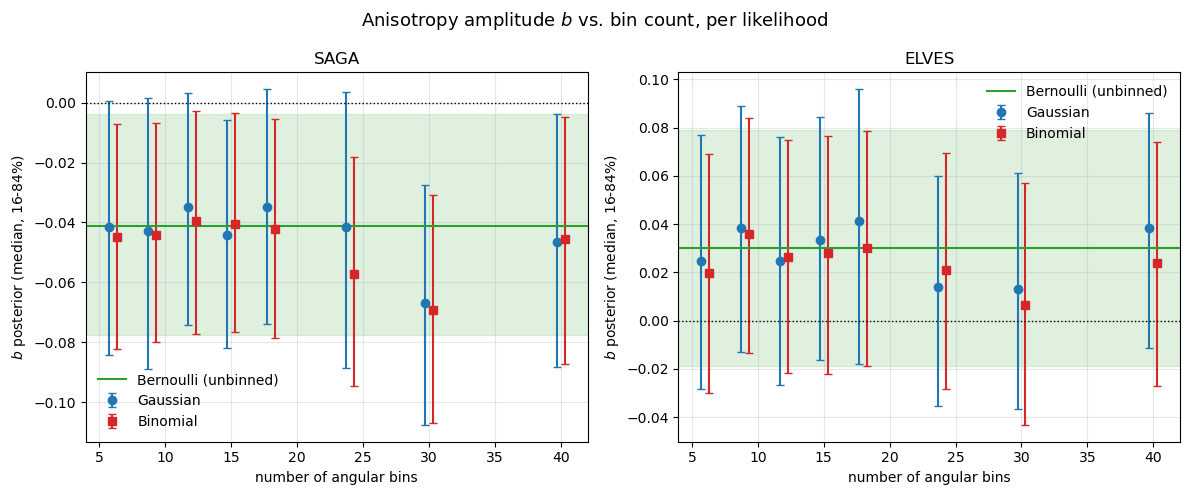

In [22]:
def _median_lo_hi(x):
    lo, med, hi = np.percentile(x, [16, 50, 84])
    return med, med - lo, hi - med

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for ax, dataset in zip(axes, ["SAGA", "ELVES"]):
    ns = [r["n_bins"] for r in sweep_records[dataset]]
    med_g, lo_g, hi_g, med_b, lo_b, hi_b = [], [], [], [], [], []
    for r in sweep_records[dataset]:
        m, lo, hi = _median_lo_hi(r["gauss_samples"][:, 1])
        med_g.append(m); lo_g.append(lo); hi_g.append(hi)
        m, lo, hi = _median_lo_hi(r["binom_samples"][:, 1])
        med_b.append(m); lo_b.append(lo); hi_b.append(hi)

    ax.errorbar(np.array(ns) - 0.3, med_g, yerr=[lo_g, hi_g], fmt="o",
                color=LIKE_COLORS["Gaussian"], capsize=3, label="Gaussian")
    ax.errorbar(np.array(ns) + 0.3, med_b, yerr=[lo_b, hi_b], fmt="s",
                color=LIKE_COLORS["Binomial"], capsize=3, label="Binomial")

    # Bernoulli (bin-independent) from section B.4 -- shown as horizontal band
    b_bern = results[dataset]["Bernoulli"][:, 1]
    m_r, lo_r, hi_r = _median_lo_hi(b_bern)
    ax.axhline(m_r, color=LIKE_COLORS["Bernoulli"], lw=1.5, label="Bernoulli (unbinned)")
    ax.axhspan(m_r - lo_r, m_r + hi_r, color=LIKE_COLORS["Bernoulli"], alpha=0.15)

    ax.axhline(0, color="k", ls=":", lw=1)
    ax.set_xlabel("number of angular bins")
    ax.set_ylabel(r"$b$ posterior (median, 16-84%)")
    ax.set_title(dataset)
    ax.legend(fontsize=10, frameon=False)
    ax.grid(alpha=0.3)
fig.suptitle(r"Anisotropy amplitude $b$ vs. bin count, per likelihood",
             fontsize=13)
fig.tight_layout()
plt.show()

#### Sweep plot: posterior on $a$ vs. bin count
Same layout; the median quenched fraction $a$ should be much more stable
with bin count than $b$ is.

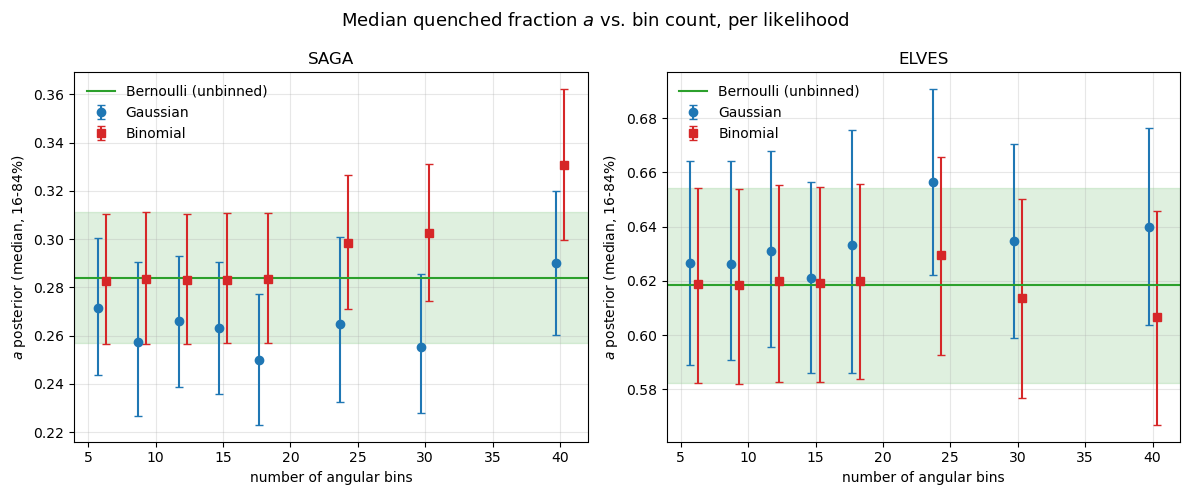

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)
for ax, dataset in zip(axes, ["SAGA", "ELVES"]):
    ns = [r["n_bins"] for r in sweep_records[dataset]]
    med_g, lo_g, hi_g, med_b, lo_b, hi_b = [], [], [], [], [], []
    for r in sweep_records[dataset]:
        m, lo, hi = _median_lo_hi(r["gauss_samples"][:, 0])
        med_g.append(m); lo_g.append(lo); hi_g.append(hi)
        m, lo, hi = _median_lo_hi(r["binom_samples"][:, 0])
        med_b.append(m); lo_b.append(lo); hi_b.append(hi)

    ax.errorbar(np.array(ns) - 0.3, med_g, yerr=[lo_g, hi_g], fmt="o",
                color=LIKE_COLORS["Gaussian"], capsize=3, label="Gaussian")
    ax.errorbar(np.array(ns) + 0.3, med_b, yerr=[lo_b, hi_b], fmt="s",
                color=LIKE_COLORS["Binomial"], capsize=3, label="Binomial")

    a_bern = results[dataset]["Bernoulli"][:, 0]
    m_r, lo_r, hi_r = _median_lo_hi(a_bern)
    ax.axhline(m_r, color=LIKE_COLORS["Bernoulli"], lw=1.5, label="Bernoulli (unbinned)")
    ax.axhspan(m_r - lo_r, m_r + hi_r, color=LIKE_COLORS["Bernoulli"], alpha=0.15)

    ax.set_xlabel("number of angular bins")
    ax.set_ylabel(r"$a$ posterior (median, 16-84%)")
    ax.set_title(dataset)
    ax.legend(fontsize=10, frameon=False)
    ax.grid(alpha=0.3)
fig.suptitle(r"Median quenched fraction $a$ vs. bin count, per likelihood",
             fontsize=13)
fig.tight_layout()
plt.show()

#### Sweep summary table

In [24]:
sweep_rows = []
for dataset in ["SAGA", "ELVES"]:
    for r in sweep_records[dataset]:
        row = {"dataset": dataset, "n_bins": r["n_bins"],
               "n_used_bins": r["n_used_bins"], "min_n_i": r["min_n_i"]}
        for lname, key in [("Gaussian", "gauss_samples"), ("Binomial", "binom_samples")]:
            a = r[key][:, 0]; b = r[key][:, 1]
            row[f"{lname}_a_med"] = float(np.median(a))
            row[f"{lname}_a_std"] = float(np.std(a))
            row[f"{lname}_b_med"] = float(np.median(b))
            row[f"{lname}_b_std"] = float(np.std(b))
        sweep_rows.append(row)
sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.to_string(index=False))

dataset  n_bins  n_used_bins  min_n_i  Gaussian_a_med  Gaussian_a_std  Gaussian_b_med  Gaussian_b_std  Binomial_a_med  Binomial_a_std  Binomial_b_med  Binomial_b_std
   SAGA       6            6       33          0.2717          0.0315         -0.0416          0.0474          0.2828          0.0272         -0.0449          0.0373
   SAGA       9            9       25          0.2576          0.0351         -0.0428          0.0502          0.2834          0.0272         -0.0442          0.0364
   SAGA      12           12       15          0.2660          0.0275         -0.0347          0.0395          0.2832          0.0270         -0.0395          0.0373
   SAGA      15           15       13          0.2631          0.0276         -0.0443          0.0386          0.2831          0.0272         -0.0405          0.0367
   SAGA      18           18        8          0.2497          0.0278         -0.0348          0.0403          0.2834          0.0271         -0.0422          0.0366
   S

**How to read the sweep.**

- **If Gaussian and Binomial track each other across bin counts and hug
  the Bernoulli band**, the likelihood choice doesn't matter and neither
  does the exact bin count within this range — the anisotropy result is
  robust.
- **If Gaussian and Binomial diverge as bin count grows** (i.e. as
  per-bin $n_i$ drops), that's the Gaussian approximation breaking down
  at small $n_i$ exactly as expected — you should trust the Binomial /
  Bernoulli columns at those bin counts.
- **If both binned likelihoods drift away from Bernoulli at the smallest
  bin counts**, that's likely under-resolution of the cosine (too few
  bins to capture the $\cos 2\theta$ shape), not a likelihood issue.
- The 18-bin column of the sweep should reproduce the 18-bin numbers
  in section B.5 to within Monte Carlo noise; the sweep uses shorter MCMC
  settings (5000 steps, 500 burn-in) than the primary comparison in B.4.

### B.8 Summary

Below is a plain-language interpretation of the comparison table and the
corner plots above. The actual numbers are printed in the summary table in
section B.5; the paragraph here explains how to read them for the
anisotropic-quenching conclusion.

- **Where the Gaussian assumption is most suspect:** section B.2 flags
  every angular bin where either $n_i p_i < 5$ or $n_i (1 - p_i) < 5$. The
  smallest-$n_i$ bin in the current SAGA/ELVES fit is around $n_i = 11$,
  and any bin where $\hat p_i$ is very close to 0 or 1 also fails the
  rule of thumb even at moderate $n_i$. Those are the bins most likely to
  distort the Gaussian log-likelihood, because the true binomial variance
  $p(1-p)/n$ vanishes in that regime and the distribution is asymmetric.

- **What "materially different" means here:** if the median of $b$ under
  the binomial or Bernoulli likelihood shifts by less than $\sim 1\sigma_b$
  (the Gaussian statistical uncertainty on $b$), the Gaussian
  approximation is adequate for the conclusion, because the shift is
  swamped by statistical noise. If the shift is larger than $\sim 1\sigma_b$
  — or if the sign / significance of $b$ flips between likelihoods — the
  anisotropy conclusion depends on the likelihood choice and the Gaussian
  result should not be trusted at face value.

- **How to read the significance change:** the `|b|/sigma_b (two-sided)`
  column is a rough z-equivalent for excluding $b = 0$. If this value
  stays above ~2 across all three likelihoods, the anisotropy detection
  is robust; if it drops below ~2 in the binomial/Bernoulli columns while
  the Gaussian was above ~2, the Gaussian was overstating the
  significance and the detection is not robust.

- **Unbinned Bernoulli as a tie-breaker:** the Bernoulli fit avoids binning
  entirely, so it is the least approximate of the three. If Bernoulli and
  binomial agree with each other but disagree with Gaussian, the
  disagreement is real (binning is not the issue; the Gaussian
  approximation is). If all three agree, the Gaussian fit is defensible
  despite the small-$n_i$ bins.

The specific numeric conclusion for this dataset is the summary table in
section B.5 combined with the shift and significance columns; the plots
in B.6 make the same story visual.